# Student Performance Analysis Notebook

Exploratory machine learning analysis of student background and academic performance using preprocessing, visualization, clustering, and classification.

## What this notebook covers

- Data loading and cleaning
- Exploratory data analysis and visualizations
- Feature encoding and scaling
- Clustering experiments with K-Means, K-Medoids-style assignment, and hierarchical clustering
- Cluster evaluation metrics
- Random Forest classification for performance grouping

In [ ]:
# Install required packages (for Google Colab or local environments)
import sys
import subprocess

# Install setuptools first (provides distutils for Python 3.12+)
packages = ['setuptools', 'pandas', 'numpy', 'seaborn', 'matplotlib', 'plotly', 'scikit-learn']

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', package, '-q'])

print(" All required packages installed successfully!")

 All required packages installed successfully!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
file = "bd_students_per_v2.csv"
df = pd.read_csv(file)
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           8612 non-null   int64 
 1   full_name                    8612 non-null   object
 2   age                          8612 non-null   int64 
 3   gender                       8612 non-null   object
 4   location                     8611 non-null   object
 5   family_size                  8612 non-null   int64 
 6   mother_education             8602 non-null   object
 7   father_education             8608 non-null   object
 8   mother_job                   8612 non-null   object
 9   father_job                   8612 non-null   object
 10  guardian                     8612 non-null   object
 11  parental_involvement         8612 non-null   object
 12  internet_access              8612 non-null   object
 13  studytime                    8612

In [ ]:
# Null Data

null_data = df.isnull().sum().sum()
print(null_data)

15


In [ ]:
# Check duplicate data

print(str(df.duplicated().sum()))

0


In [ ]:
# Numeric features

df.iloc[:, :].describe().T.sort_values(by='std' , ascending = False)

,count,mean,std,min,25%,50%,75%,max
id,8612.0,4307.500000,2486.214593,2.0,2154.75,4307.5,6460.25,8613.0
math,8612.0,72.938110,15.816147,33.0,64.00,73.0,84.00,100.0
english,8612.0,73.610427,15.343903,18.0,64.00,75.0,85.00,100.0
science,8612.0,73.524036,15.115104,33.0,63.00,75.0,85.00,100.0
social_science,8612.0,74.465513,14.945846,36.0,65.00,77.0,86.00,100.0
art_culture,8612.0,76.236066,13.619125,36.0,69.00,76.0,86.00,100.0
attendance,8612.0,74.027055,13.290046,30.0,63.00,73.0,86.00,100.0
studytime,8612.0,4.746168,2.185645,1.0,3.00,5.0,6.00,16.0
family_size,8612.0,4.502206,1.656726,0.0,3.00,5.0,6.00,11.0
age,8612.0,16.614375,0.969057,10.0,16.00,17.0,17.00,24.0


Now, we'll change the position of the columns, leaving the performance columns last.

In [ ]:

df = df[['id', 'full_name', 'age', 'gender', 'location', 'stu_group', 'family_size',
       'mother_education', 'father_education', 'mother_job', 'father_job',
       'guardian', 'parental_involvement', 'internet_access', 'studytime',
       'tutoring', 'school_type', 'attendance', 'extra_curricular_activities',
       'english', 'math', 'science', 'social_science', 'art_culture']]

In [ ]:
df.head()

,id,full_name,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,...,studytime,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture
0,2,Avi Biswas,16,Male,Urban,Science,6,SSC,HSC,No,...,8,Yes,Private,95,Yes,95,98,92,94,98
1,3,Taslima Sultana,18,Female,Rural,Commerce,6,SSC,HSC,No,...,4,No,Semi_Govt,92,No,65,71,40,78,80
2,4,Md Adilur Rahman,15,Male,Rural,Commerce,4,SSC,SSC,Yes,...,5,Yes,Govt,81,Yes,64,78,58,86,74
3,5,Saleh Ahmed,16,Male,Rural,Science,6,SSC,SSC,Yes,...,7,Yes,Private,90,Yes,84,90,85,86,88
4,6,Din Islam,17,Male,Urban,Commerce,5,Honors,Masters,No,...,4,Yes,Semi_Govt,75,Yes,54,70,45,79,76


In [ ]:
cols = ['age', 'gender', 'location', 'stu_group',
       'family_size', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'guardian', 'parental_involvement', 'internet_access',
       'studytime', 'tutoring', 'school_type', 'extra_curricular_activities']

Now, we'll be Checking performances by feature

******************************************* age ****************************************


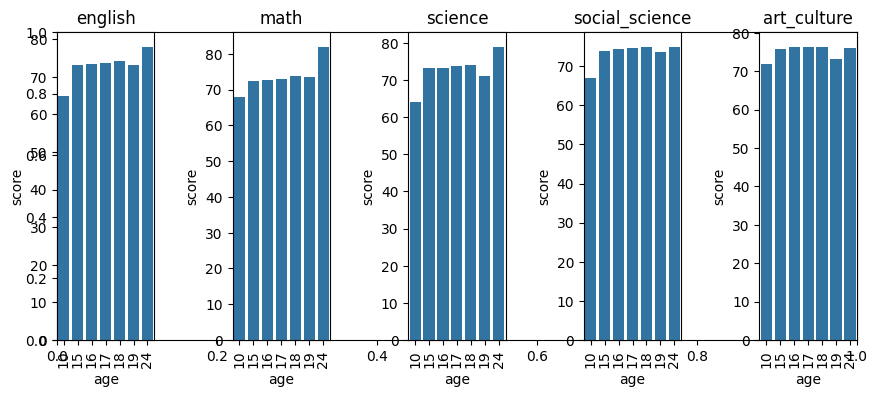

******************************************* gender ****************************************


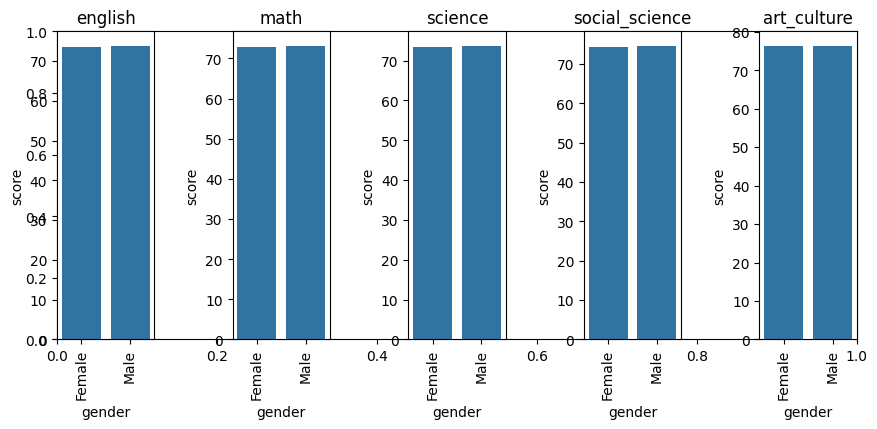

******************************************* location ****************************************


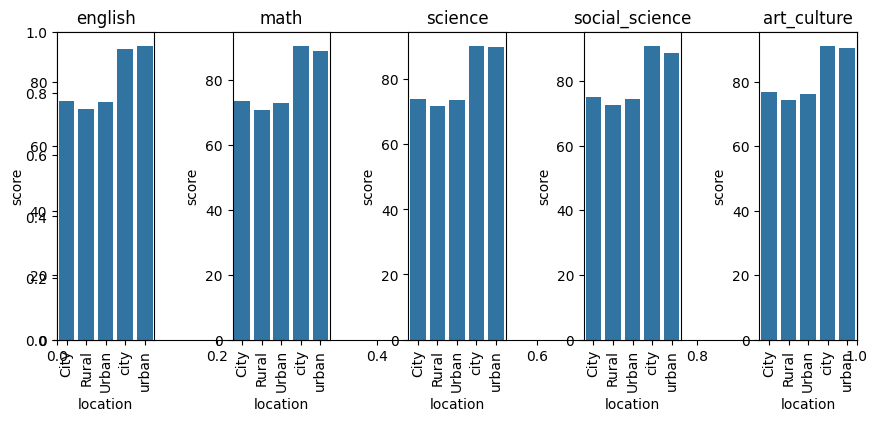

******************************************* stu_group ****************************************


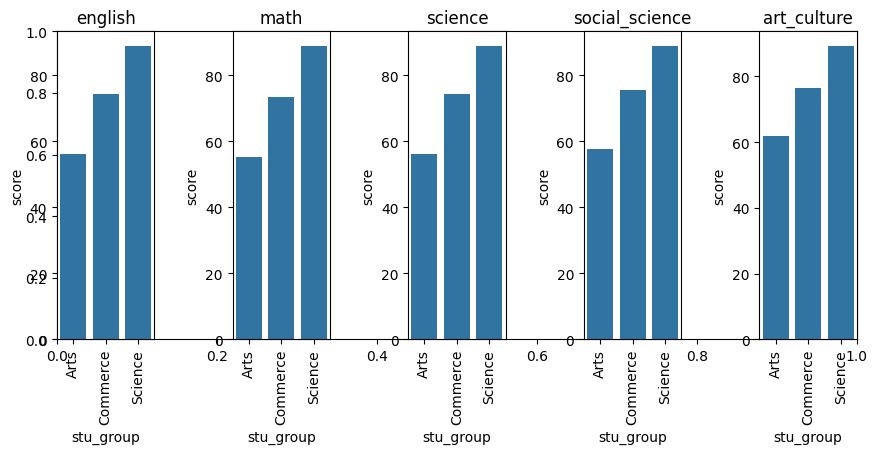

******************************************* family_size ****************************************


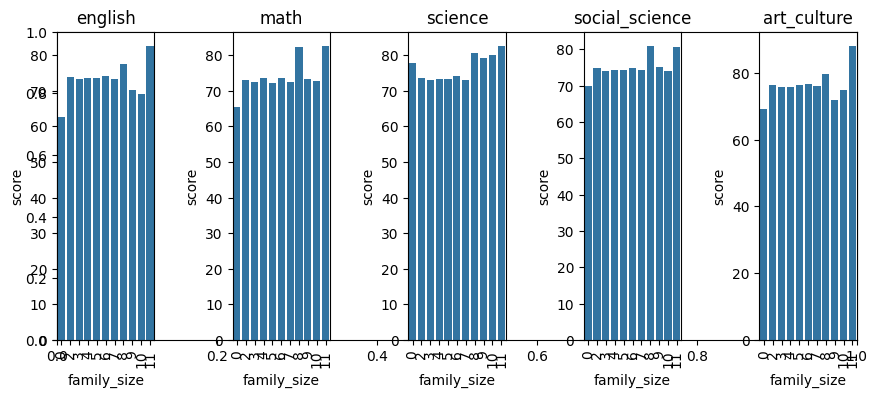

******************************************* mother_education ****************************************


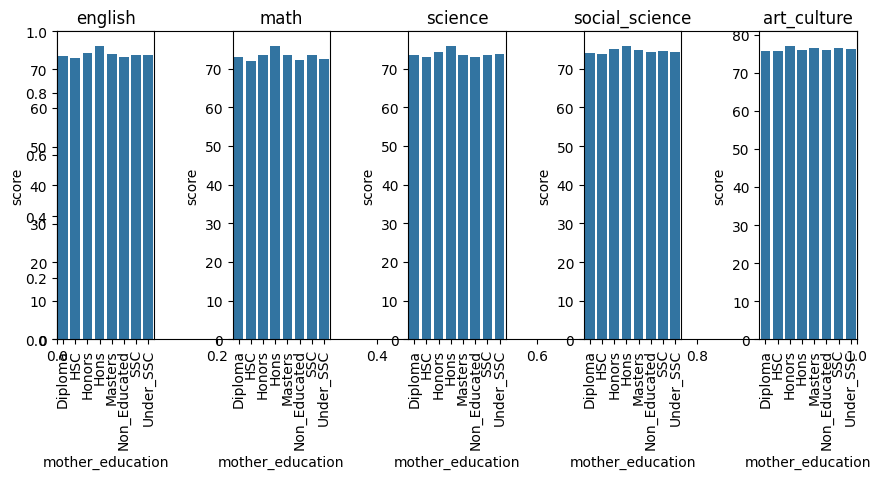

******************************************* father_education ****************************************


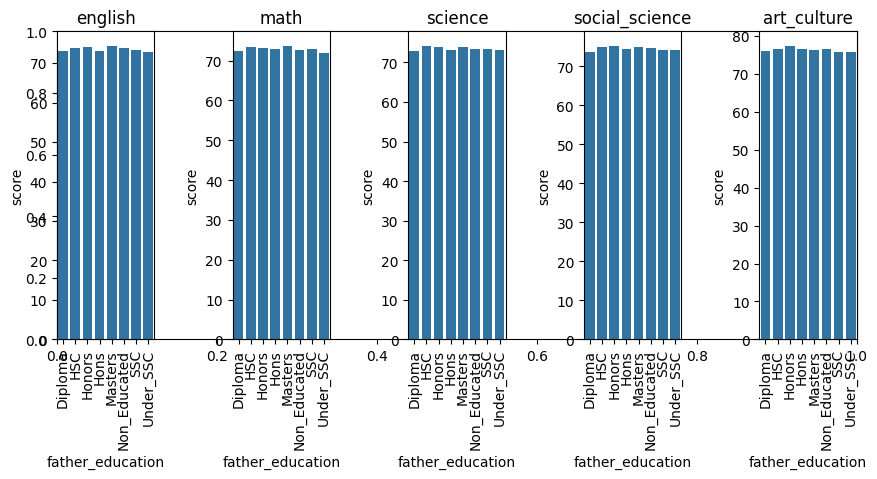

******************************************* mother_job ****************************************


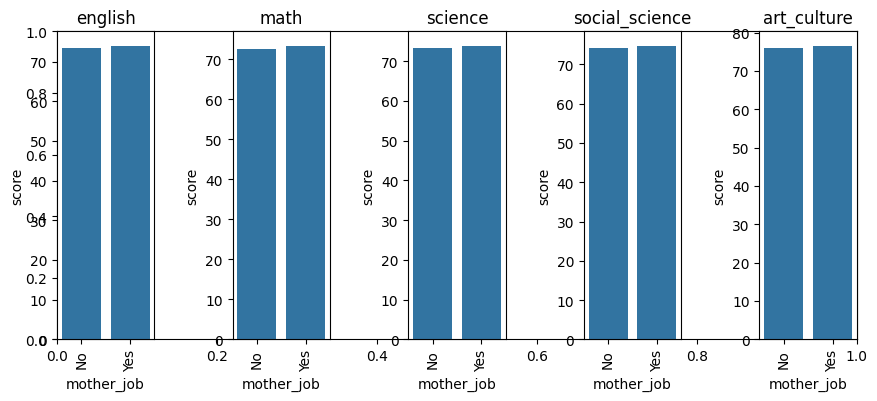

******************************************* father_job ****************************************


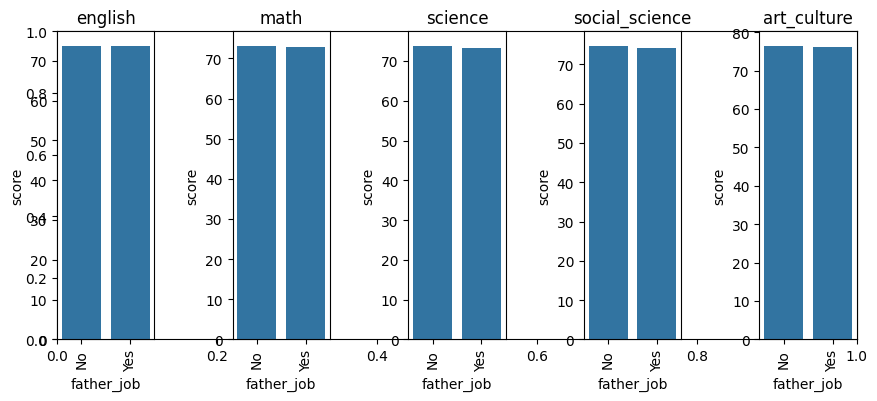

******************************************* guardian ****************************************


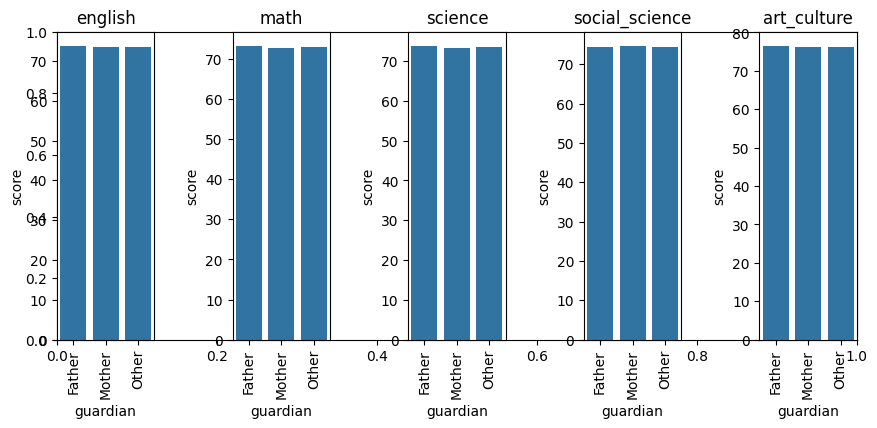

******************************************* parental_involvement ****************************************


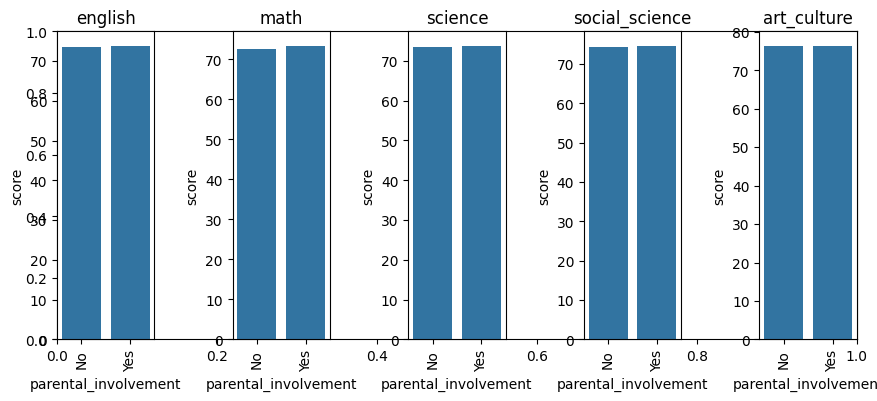

******************************************* internet_access ****************************************


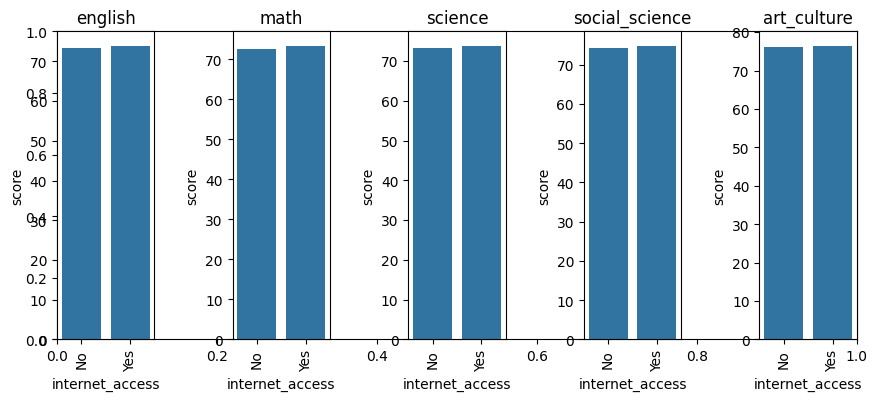

******************************************* studytime ****************************************


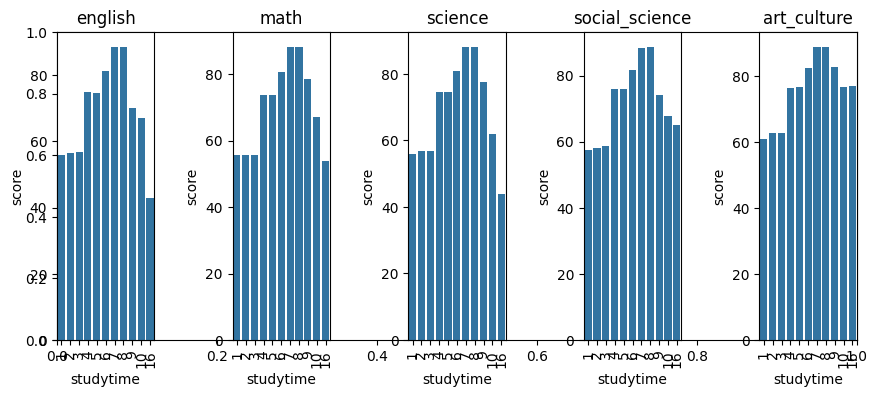

******************************************* tutoring ****************************************


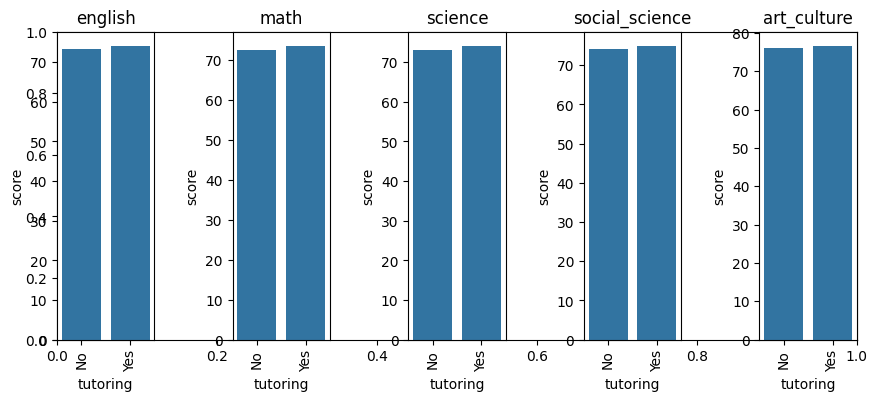

******************************************* school_type ****************************************


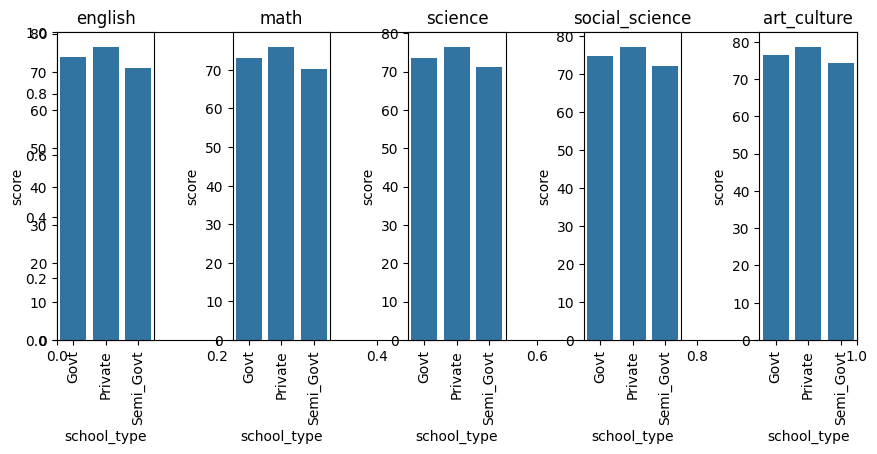

******************************************* extra_curricular_activities ****************************************


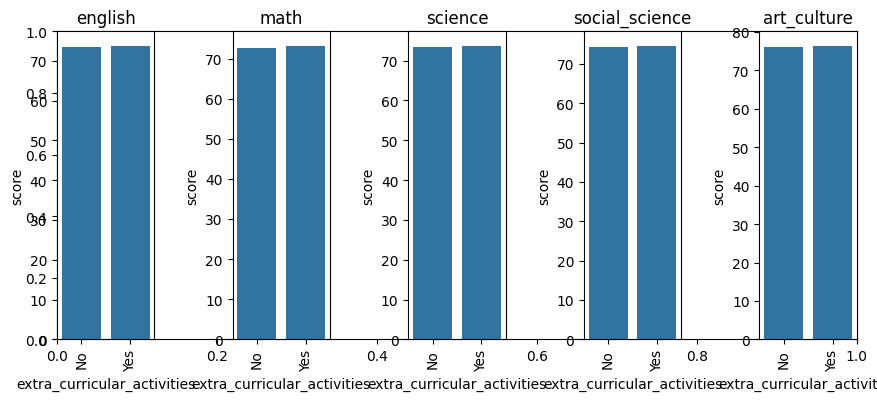

In [ ]:


for i in cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.subplots_adjust(hspace=0.8, wspace=0.8, left = 0.2, right = 1.0)
    for idx in range(5):
        plt.subplot(1,5, idx+1)
        group_stats = df.groupby([i])[list(df.columns[-5:])[idx]].describe()
        sns.barplot(x = group_stats.index, y = group_stats.loc[:,"mean"].values)
        plt.ylabel("score")
        plt.xticks(rotation=90)
        plt.title(list(df.columns[-5:])[idx])
    print('*******************************************', i, '****************************************')

    plt.show()

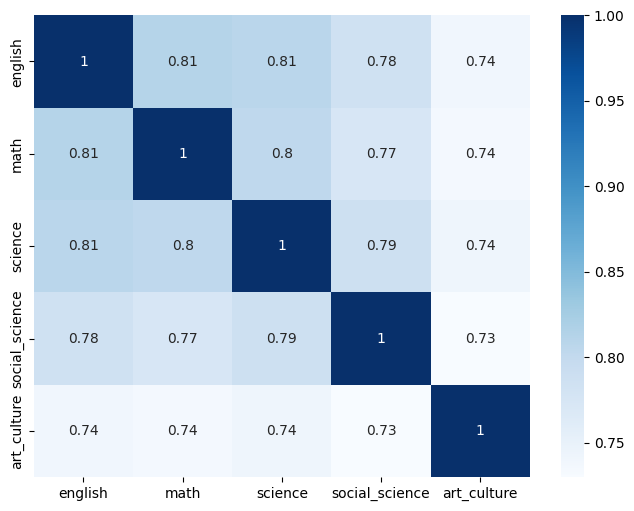

In [ ]:
# Heatmap of performances

df_score = df[['english', 'math', 'science',
       'social_science', 'art_culture']]

plt.figure(figsize=(8,6))
sns.heatmap(df_score.corr(),annot=True, cmap='Blues');

K Means Clustering

In [ ]:
# Delete unnecessary columns
df.drop(["id", "full_name", "attendance"], axis=1, inplace=True)

In [ ]:
# Delete null data
df = df.dropna()

In [ ]:
# Convert the columns to numeric - Label Encoding

le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == object:
        df[column] = le.fit_transform(df[column])

In [ ]:
df_final = df.copy()

# Scale the features for clustering
scaled_X = StandardScaler().fit_transform(df_final)

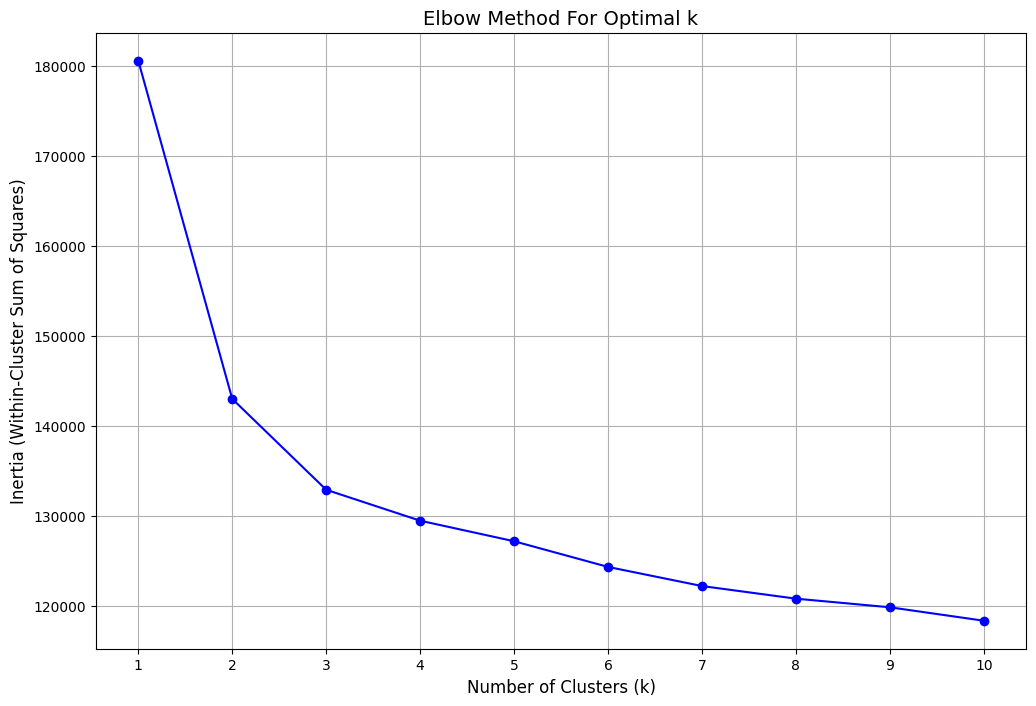

Optimal k appears to be around 3 clusters


In [ ]:
# Elbow Method to find optimal number of clusters
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(scaled_X)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(12, 8))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method For Optimal k', fontsize=14)
plt.grid(True)
plt.xticks(K_range)
plt.show()

print(f"Optimal k appears to be around 3 clusters")

In [ ]:
# KMeans with 3 clusters

kmeans = KMeans(init = "k-means++", n_clusters = 3)
kmeans.fit_transform(scaled_X)
kmeans_label = kmeans.labels_
df["cluster"] = kmeans_label
df.head()

,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,father_job,guardian,...,studytime,tutoring,school_type,extra_curricular_activities,english,math,science,social_science,art_culture,cluster
0,16,1,2,2,6,6,1,0,0,0,...,8,1,1,1,95,98,92,94,98,2
1,18,0,1,1,6,6,1,0,1,0,...,4,0,2,0,65,71,40,78,80,0
2,15,1,1,1,4,6,6,1,1,0,...,5,1,0,1,64,78,58,86,74,0
3,16,1,1,2,6,6,6,1,1,0,...,7,1,1,1,84,90,85,86,88,2
4,17,1,2,1,5,2,4,0,1,0,...,4,1,2,1,54,70,45,79,76,0


## K-Medoids (PAM) Clustering

In [ ]:
# K-Medoids implementation using KMeans with different metric approach
from sklearn.metrics import pairwise_distances
import numpy as np

# Simple K-Medoids implementation
n_clusters = 3
random_state = 123
np.random.seed(random_state)

# Initialize with random medoids
n_samples = scaled_X.shape[0]
medoid_indices = np.random.choice(n_samples, n_clusters, replace=False)
medoids = scaled_X[medoid_indices]

# Assign clusters based on distance to medoids
distances = pairwise_distances(scaled_X, medoids, metric='euclidean')
kmedoids_labels = np.argmin(distances, axis=1)

# Add K-Medoids cluster labels to df_final
df_final['kmedoids_cluster'] = kmedoids_labels
print("K-Medoids clustering completed!")
print(f"\nCluster distribution:")
print(df_final['kmedoids_cluster'].value_counts().sort_index())

K-Medoids clustering completed!

Cluster distribution:
kmedoids_cluster
0    1192
1    4435
2    2972
Name: count, dtype: int64


## Hierarchical Clustering

In [ ]:
# Hierarchical Clustering with 3 clusters
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(scaled_X)

# Add Hierarchical cluster labels to df_final
df_final['hierarchical_cluster'] = hierarchical_labels
print("Hierarchical clustering completed!")
print(f"\nCluster distribution:")
print(df_final['hierarchical_cluster'].value_counts().sort_index())

Hierarchical clustering completed!

Cluster distribution:
hierarchical_cluster
0    3296
1    2594
2    2709
Name: count, dtype: int64


## Cluster Evaluation Metrics

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate metrics for all three clustering methods
methods = {
    'KMeans': kmeans_label,
    'K-Medoids': kmedoids_labels,
    'Hierarchical': hierarchical_labels
}


results = []
for method_name, labels in methods.items():
    silhouette = silhouette_score(scaled_X, labels)
    dbi = davies_bouldin_score(scaled_X, labels)
    chi = calinski_harabasz_score(scaled_X, labels)

    results.append({
        'Method': method_name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

    print(f"\n{method_name}:")
    print(f"  Silhouette Score:         {silhouette:.4f} (Higher is better)")
    print(f"  Davies-Bouldin Index:     {dbi:.4f} (Lower is better)")
    print(f"  Calinski-Harabasz Index:  {chi:.2f} (Higher is better)")




KMeans:
  Silhouette Score:         0.1050 (Higher is better)
  Davies-Bouldin Index:     2.7301 (Lower is better)
  Calinski-Harabasz Index:  1541.95 (Higher is better)

K-Medoids:
  Silhouette Score:         0.0730 (Higher is better)
  Davies-Bouldin Index:     3.2344 (Lower is better)
  Calinski-Harabasz Index:  909.13 (Higher is better)

Hierarchical:
  Silhouette Score:         0.1016 (Higher is better)
  Davies-Bouldin Index:     2.7760 (Lower is better)
  Calinski-Harabasz Index:  1493.97 (Higher is better)


In [ ]:
# Determine best method for each metric
print("BEST PERFORMING METHOD PER METRIC:")

best_silhouette = max(results, key=lambda x: x['Silhouette Score'])
best_dbi = min(results, key=lambda x: x['Davies-Bouldin Index'])
best_chi = max(results, key=lambda x: x['Calinski-Harabasz Index'])

print(f"\n Best Silhouette Score:        {best_silhouette['Method']} ({best_silhouette['Silhouette Score']:.4f})")
print(f" Best Davies-Bouldin Index:   {best_dbi['Method']} ({best_dbi['Davies-Bouldin Index']:.4f})")
print(f" Best Calinski-Harabasz Index: {best_chi['Method']} ({best_chi['Calinski-Harabasz Index']:.2f})")

# Overall recommendation
print("\nOVERALL RECOMMENDATION:")
votes = {}
for method in [best_silhouette['Method'], best_dbi['Method'], best_chi['Method']]:
    votes[method] = votes.get(method, 0) + 1

best_overall = max(votes, key=votes.get)
print(f"\n {best_overall} performs best overall (best in {votes[best_overall]}/3 metrics)")

BEST PERFORMING METHOD PER METRIC:

 Best Silhouette Score:        KMeans (0.1050)
 Best Davies-Bouldin Index:   KMeans (2.7301)
 Best Calinski-Harabasz Index: KMeans (1541.95)

OVERALL RECOMMENDATION:

 KMeans performs best overall (best in 3/3 metrics)


In [ ]:
# Keep only the best performing cluster (KMeans) in df_final
# Remove the other clustering columns if they exist
columns_to_drop = [col for col in ['kmedoids_cluster', 'hierarchical_cluster'] if col in df_final.columns]
if columns_to_drop:
    df_final.drop(columns_to_drop, axis=1, inplace=True)
    print(f"Removed columns: {columns_to_drop}")

# Add the KMeans cluster from df to df_final if not already present
if 'cluster' not in df_final.columns:
    df_final['cluster'] = df['cluster'].values

print("\nDataframe updated with only KMeans clustering results.")
print(f"Final dataframe shape: {df_final.shape}")
print(f"Cluster column: 'cluster' (KMeans)")
print(f"\nCluster distribution:")
print(df_final['cluster'].value_counts().sort_index())

Removed columns: ['kmedoids_cluster', 'hierarchical_cluster']

Dataframe updated with only KMeans clustering results.
Final dataframe shape: (8599, 22)
Cluster column: 'cluster' (KMeans)

Cluster distribution:
cluster
0    3173
1    2628
2    2798
Name: count, dtype: int64


## DETAIL ANALYSIS OF THE BEST METHOD

In [ ]:
# Checking the number of students in each cluster

freq = df['cluster'].value_counts()
print(freq)

cluster
0    3173
2    2798
1    2628
Name: count, dtype: int64


In [ ]:
# Checking the scores of each cluster using "mean"

class_df = df.groupby("cluster")[df.columns[-6:-1]].mean()
class_df

,english,math,science,social_science,art_culture
cluster,,,,,
0,74.558462,73.538922,74.324614,75.558777,76.338166
1,55.364916,54.407915,55.653349,57.056697,61.500761
2,89.697641,89.685490,89.436026,89.617584,90.005004


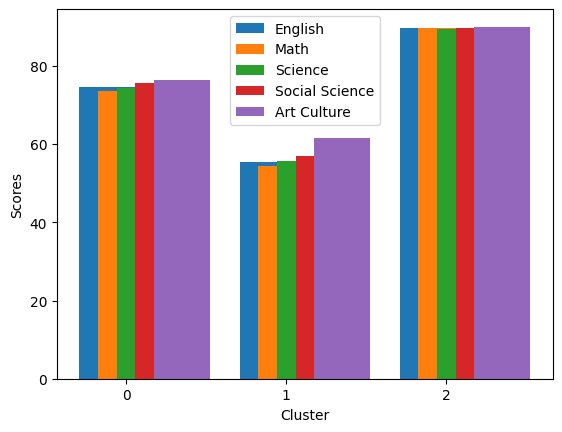

In [ ]:
# Bar chart with the scores for each cluster

ind = np.arange(3)
width = 0.35
fig, ax = plt.subplots()
#fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(ind - width/3, class_df.english, width, label='English')
rects2 = ax.bar(ind, class_df.math, width, label='Math')
rects3 = ax.bar(ind + width/3, class_df.science, width, label='Science')
rects4 = ax.bar(ind + width/1.5, class_df.social_science, width, label='Social Science')
rects5 = ax.bar(ind + width/1, class_df.art_culture, width, label='Art Culture')


ax.set_xlabel('Cluster')
ax.set_ylabel('Scores')
ax.set_xticks(ind)
ax.legend()
plt.show()

In [ ]:
# Making an average score for each cluster

class_df["total_ave_score"] = (class_df.english + class_df.math + class_df.science + class_df.social_science + class_df.art_culture)/5
rank = class_df["total_ave_score"].sort_values(ascending = False)
rank.index

Index([2, 0, 1], dtype='int32', name='cluster')

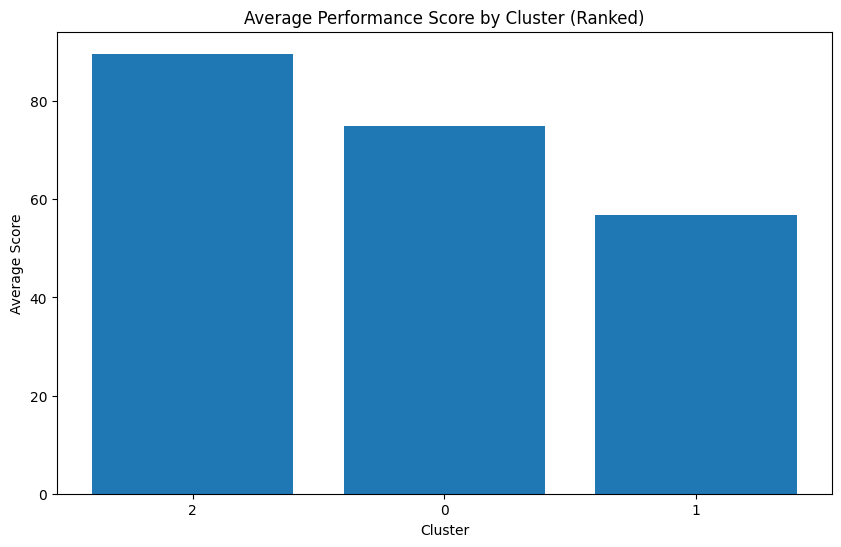


Cluster Ranking (Best to Worst):
1. Cluster 2: 89.69
2. Cluster 0: 74.86
3. Cluster 1: 56.80


In [ ]:
# Bar chart visualization of average scores by cluster

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rank.index.astype(str), rank.values)

ax.set_xlabel('Cluster')
ax.set_ylabel('Average Score')
ax.set_title('Average Performance Score by Cluster (Ranked)')
plt.show()

# Print cluster ranking
print("\nCluster Ranking (Best to Worst):")
for i, (cluster, score) in enumerate(zip(rank.index, rank.values), 1):
    print(f"{i}. Cluster {cluster}: {score:.2f}")

### Key Socioeconomic Factors Analysis

The research examines relationships between socioeconomic factors and academic achievement across five core subjects: English, Mathematics, Science, Social Science, and Art Culture.

In [ ]:
# Analyze top socioeconomic factors that differentiate performance clusters
# Features to analyze (socioeconomic factors)
socioeconomic_features = [
    'mother_education', 'father_education', 'internet_access',
    'tutoring', 'school_type', 'studytime', 'parental_involvement',
    'family_size', 'guardian', 'mother_job', 'father_job',
    'location', 'extra_curricular_activities'
]

# Performance indicators (subjects)
performance_features = ['english', 'math', 'science', 'social_science', 'art_culture']

# Calculate mean values for each socioeconomic factor by cluster
cluster_profiles = df.groupby('cluster')[socioeconomic_features].mean()

# Calculate the variance of each feature across clusters
# Higher variance = better differentiator
feature_variance = cluster_profiles.var(axis=0).sort_values(ascending=False)


print("TOP SOCIOECONOMIC FACTORS DIFFERENTIATING PERFORMANCE CLUSTERS")
print("\nFeature Variance Across Clusters (Higher = More Differentiating):\n")

# Display top factors
top_n = 10
for idx, (feature, variance) in enumerate(feature_variance.head(top_n).items(), 1):
    print(f"{idx:2d}. {feature:30s} - Variance: {variance:.4f}")



TOP SOCIOECONOMIC FACTORS DIFFERENTIATING PERFORMANCE CLUSTERS

Feature Variance Across Clusters (Higher = More Differentiating):

 1. studytime                      - Variance: 5.8114
 2. school_type                    - Variance: 0.0111
 3. location                       - Variance: 0.0074
 4. father_education               - Variance: 0.0066
 5. mother_education               - Variance: 0.0040
 6. guardian                       - Variance: 0.0035
 7. family_size                    - Variance: 0.0018
 8. father_job                     - Variance: 0.0015
 9. internet_access                - Variance: 0.0013
10. mother_job                     - Variance: 0.0009


In [ ]:
# Identify top 3 key factors
top_3_factors = feature_variance.head(3).index.tolist()
print("TOP 3 KEY SOCIOECONOMIC FACTORS:")
for idx, factor in enumerate(top_3_factors, 1):
    print(f"{idx}. {factor.upper()}")
    print(f"   Cluster Means:")
    for cluster_id in sorted(df['cluster'].unique()):
        mean_val = cluster_profiles.loc[cluster_id, factor]
        print(f"      Cluster {cluster_id}: {mean_val:.3f}")
    print()

TOP 3 KEY SOCIOECONOMIC FACTORS:
1. STUDYTIME
   Cluster Means:
      Cluster 0: 5.048
      Cluster 1: 2.105
      Cluster 2: 6.884

2. SCHOOL_TYPE
   Cluster Means:
      Cluster 0: 0.939
      Cluster 1: 1.115
      Cluster 2: 0.928

3. LOCATION
   Cluster Means:
      Cluster 0: 0.998
      Cluster 1: 1.005
      Cluster 2: 1.150



In [ ]:
# Detailed analysis: Average academic scores by top 3 factors


# Add average performance to each cluster
cluster_performance = df.groupby('cluster')[performance_features].mean()
cluster_performance['avg_performance'] = cluster_performance.mean(axis=1)

# Display comprehensive cluster summary
print("\nCluster Performance Summary:")
for cluster_id in sorted(df['cluster'].unique()):
    print(f"\nCluster {cluster_id}:")
    print(f"  Average Performance Score: {cluster_performance.loc[cluster_id, 'avg_performance']:.2f}")
    print(f"  Top 3 Factor Values:")
    for factor in top_3_factors:
        print(f"    - {factor}: {cluster_profiles.loc[cluster_id, factor]:.3f}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print(f"""
The analysis reveals that {top_3_factors[0]}, {top_3_factors[1]}, and {top_3_factors[2]}
are the most significant socioeconomic differentiators between performance clusters.

These factors show the highest variance across clusters, indicating they play
crucial roles in determining student academic achievement across all five subjects.
""")


Cluster Performance Summary:

Cluster 0:
  Average Performance Score: 74.86
  Top 3 Factor Values:
    - studytime: 5.048
    - school_type: 0.939
    - location: 0.998

Cluster 1:
  Average Performance Score: 56.80
  Top 3 Factor Values:
    - studytime: 2.105
    - school_type: 1.115
    - location: 1.005

Cluster 2:
  Average Performance Score: 89.69
  Top 3 Factor Values:
    - studytime: 6.884
    - school_type: 0.928
    - location: 1.150

KEY INSIGHTS:

The analysis reveals that studytime, school_type, and location 
are the most significant socioeconomic differentiators between performance clusters.

These factors show the highest variance across clusters, indicating they play 
crucial roles in determining student academic achievement across all five subjects.



## Predictive Modeling: Cluster Classification

Build a classifier to predict which performance cluster a new student belongs to based on socioeconomic factors.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (socioeconomic factors only, exclude performance scores)
socioeconomic_features = [
    'age', 'gender', 'location', 'stu_group', 'family_size',
    'mother_education', 'father_education', 'mother_job', 'father_job',
    'guardian', 'parental_involvement', 'internet_access',
    'studytime', 'tutoring', 'school_type', 'extra_curricular_activities'
]

# Prepare the data
X = df[socioeconomic_features]
y = df['cluster']

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} students")
print(f"Testing set size: {len(X_test)} students")
print(f"\nCluster distribution in training set:")
print(y_train.value_counts().sort_index())

Training set size: 6879 students
Testing set size: 1720 students

Cluster distribution in training set:
cluster
0    2538
1    2103
2    2238
Name: count, dtype: int64


In [ ]:
# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[f'Cluster {i}' for i in sorted(y.unique())]))

Model Accuracy: 97.97%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.98      0.97      0.97       635
   Cluster 1       0.99      0.98      0.98       525
   Cluster 2       0.98      0.99      0.98       560

    accuracy                           0.98      1720
   macro avg       0.98      0.98      0.98      1720
weighted avg       0.98      0.98      0.98      1720



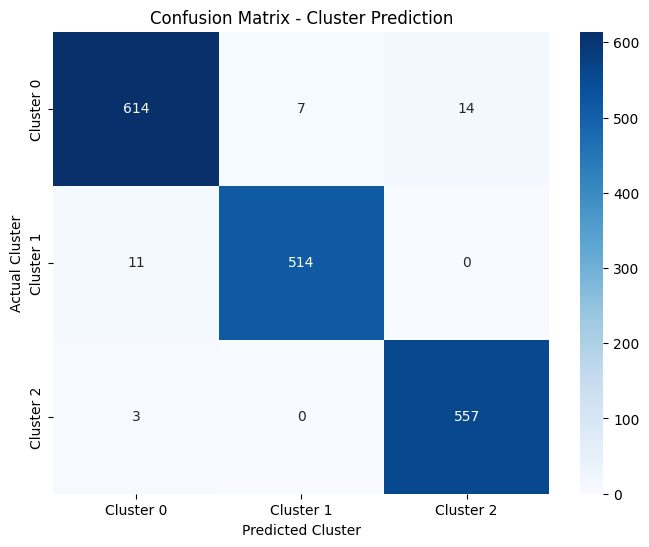

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in sorted(y.unique())],
            yticklabels=[f'Cluster {i}' for i in sorted(y.unique())])
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.title('Confusion Matrix - Cluster Prediction')
plt.show()

Top 10 Most Important Features for Cluster Prediction:
         Feature  Importance
       stu_group    0.591275
       studytime    0.344339
        location    0.012910
             age    0.009163
father_education    0.006668
mother_education    0.005896
     family_size    0.005597
     school_type    0.005554
        guardian    0.003646
      father_job    0.003160


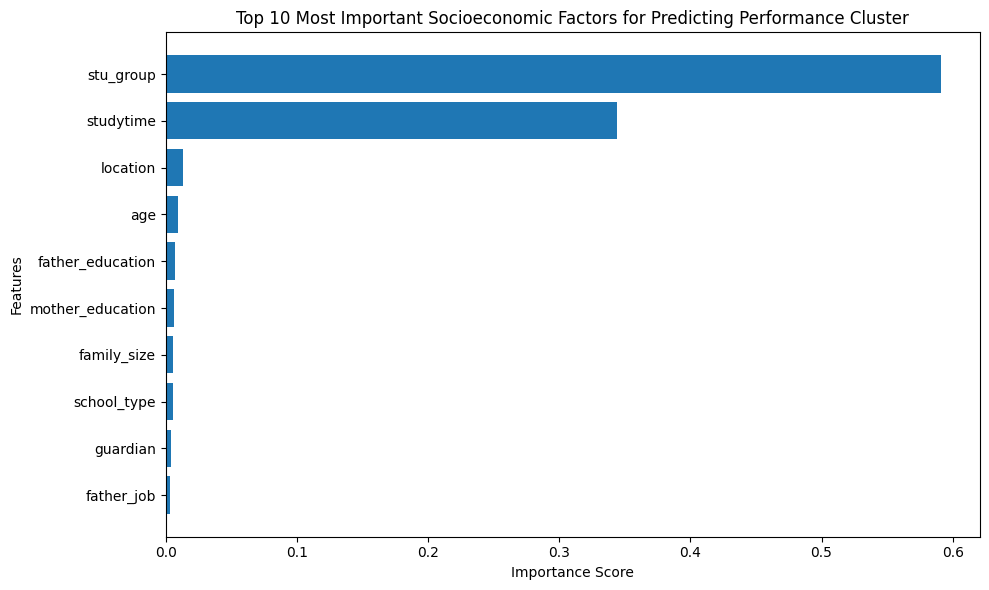

In [ ]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': socioeconomic_features,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features for Cluster Prediction:")
print(feature_importance.head(10).to_string(index=False))

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Most Important Socioeconomic Factors for Predicting Performance Cluster')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Example: Predict cluster for a new student
# Create a sample student profile
new_student = pd.DataFrame({
    'age': [1],  # Encoded value
    'gender': [0],  # Encoded value
    'location': [1],  # Encoded value
    'stu_group': [0],  # Encoded value
    'family_size': [1],  # Encoded value
    'mother_education': [2],  # Encoded value (higher education)
    'father_education': [2],  # Encoded value (higher education)
    'mother_job': [2],  # Encoded value
    'father_job': [2],  # Encoded value
    'guardian': [1],  # Encoded value
    'parental_involvement': [2],  # Encoded value (high involvement)
    'internet_access': [1],  # Encoded value (has internet)
    'studytime': [2],  # Encoded value (more study time)
    'tutoring': [1],  # Encoded value (has tutoring)
    'school_type': [1],  # Encoded value
    'extra_curricular_activities': [1]  # Encoded value (participates)
})

predicted_cluster = rf_classifier.predict(new_student)[0]
prediction_proba = rf_classifier.predict_proba(new_student)[0]

print("Example Prediction for New Student:")
print(f"\nPredicted Cluster: {predicted_cluster}")
print(f"\nPrediction Probabilities:")
for cluster_id, prob in enumerate(prediction_proba):
    print(f"  Cluster {cluster_id}: {prob:.2%}")

print(f"\n✓ This student is most likely to be in Cluster {predicted_cluster}")

Example Prediction for New Student:

Predicted Cluster: 1

Prediction Probabilities:
  Cluster 0: 7.43%
  Cluster 1: 92.48%
  Cluster 2: 0.09%

✓ This student is most likely to be in Cluster 1
